# Speed Dating — Qu'est-ce qui fait qu'on se plaît ?

**Contexte** : Tinder veut comprendre pourquoi les matchs baissent. Une expérience de speed dating (2002–2004) a enregistré 8 378 rendez-vous de 4 minutes entre 551 participants.

---

| Participants | Rendez-vous | Taux de « oui » | Taux de match |
|:---:|:---:|:---:|:---:|
| 551 | 8 378 | 42 % | 16,5 % |

---

**5 questions :**
1. Que recherchent hommes et femmes ?
2. Discours vs comportement réel sur l'attractivité
3. Intérêts communs vs même origine
4. Les gens connaissent-ils leur propre valeur ?
5. Mieux vaut-il passer en premier ou en dernier ?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('Speed+Dating+Data.csv', encoding='ISO-8859-1')

# Normalisation des préférences déclarées sur 100
cols_stated = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']
labels_fr   = ['Physique', 'Sincérité', 'Intelligence', 'Fun', 'Ambition', 'Intérêts communs']
df_clean = df.copy()
total = df_clean[cols_stated].sum(axis=1)
mask = total > 0
for col in cols_stated:
    df_clean.loc[mask, col] = df_clean.loc[mask, col] / total[mask] * 100

prefs = df_clean.dropna(subset=cols_stated).groupby(['iid', 'gender'])[cols_stated].first().reset_index()
print('Prêt —', df.shape[0], 'lignes,', df['iid'].nunique(), 'participants')

Prêt — 8378 lignes, 551 participants


---
## Q1 — Que recherchent les hommes et les femmes ?

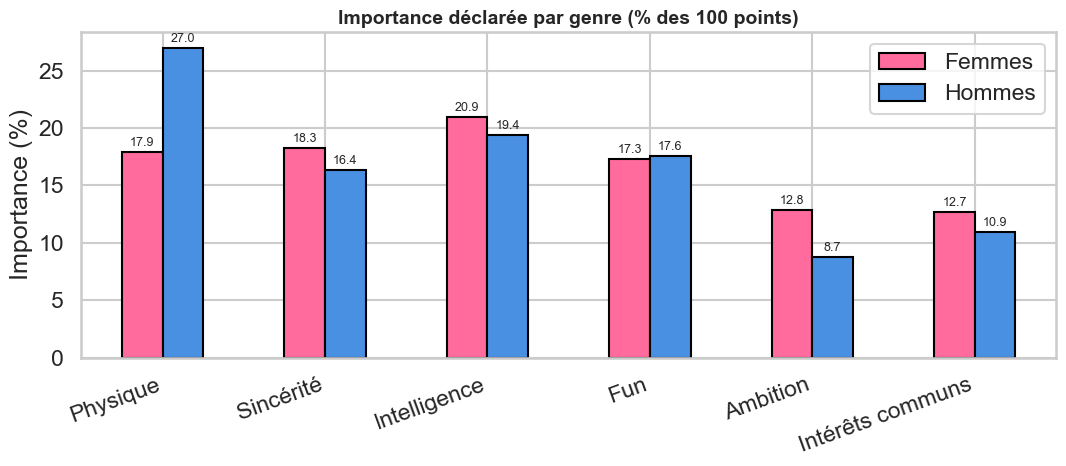

In [2]:
moyennes = prefs.groupby('gender')[cols_stated].mean()
moyennes.index = ['Femmes', 'Hommes']
moyennes.columns = labels_fr

ax = moyennes.T.plot(kind='bar', figsize=(11, 5),
                     color=['#ff6b9d', '#4a90e2'], edgecolor='black')
ax.set_title('Importance déclarée par genre (% des 100 points)', fontsize=14, weight='bold')
ax.set_ylabel('Importance (%)')
plt.xticks(rotation=20, ha='right')
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f', fontsize=9, padding=2)
plt.tight_layout()
plt.show()

**Résultat clé :** Les hommes accordent **~50 % de plus** au physique que les femmes (27 % vs 18 %). Les femmes valorisent davantage l'intelligence et la sincérité. L'ambition est le critère le moins cité par les deux genres.

---
## Q2 — Discours vs comportement réel sur l'attractivité

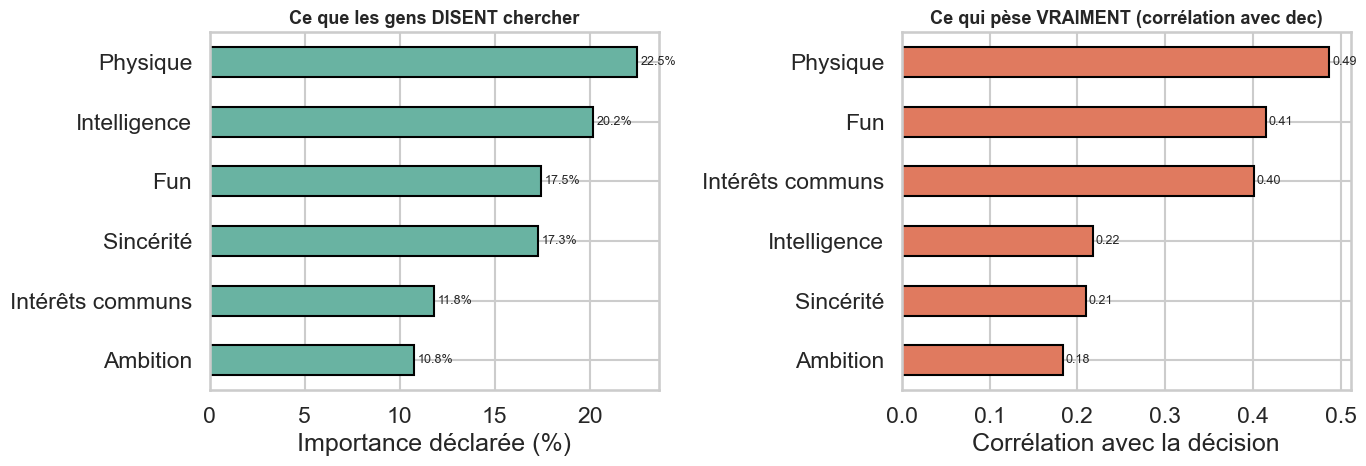

In [3]:
real_factors = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
corr_real = df[['dec'] + real_factors].corr()['dec'].drop('dec')
corr_real.index = labels_fr
declare = prefs[cols_stated].mean()
declare.index = labels_fr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
declare.sort_values().plot(kind='barh', ax=axes[0], color='#69b3a2', edgecolor='black')
axes[0].set_title('Ce que les gens DISENT chercher', fontsize=13, weight='bold')
axes[0].set_xlabel('Importance déclarée (%)')
for i, v in enumerate(declare.sort_values()):
    axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

corr_real.sort_values().plot(kind='barh', ax=axes[1], color='#e07a5f', edgecolor='black')
axes[1].set_title('Ce qui pèse VRAIMENT (corrélation avec dec)', fontsize=13, weight='bold')
axes[1].set_xlabel('Corrélation avec la décision')
for i, v in enumerate(corr_real.sort_values()):
    axes[1].text(v + 0.003, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Résultat clé :** Le physique est le facteur n°1 réel (corrélation **0,49**) mais déclaré n°3 seulement. Intelligence et sincérité sont **surestimées dans le discours**. L'ambition est le facteur le plus faible — et le moins utilisé.

---
## Q3 — Intérêts communs vs même origine

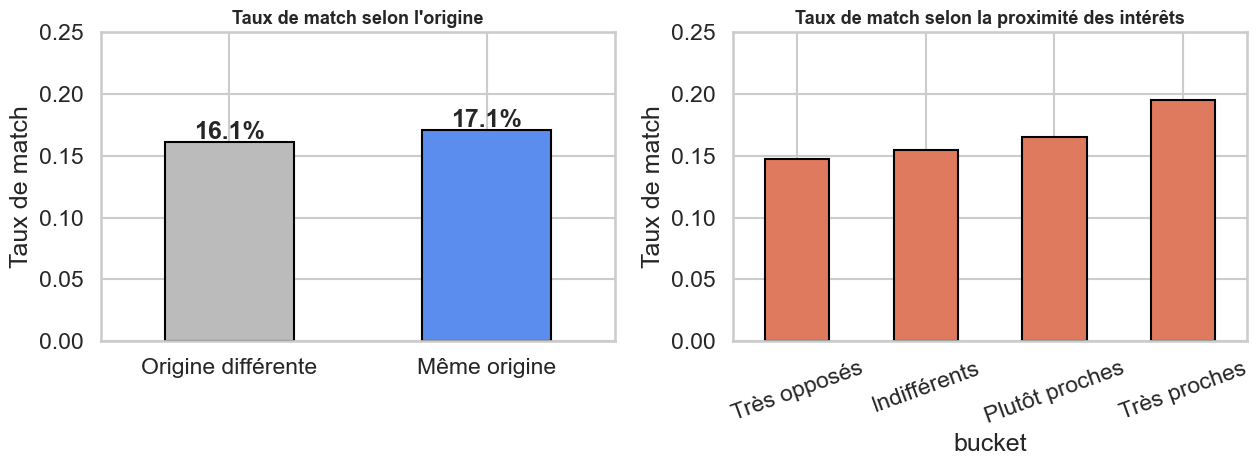

In [4]:
df_plot = df.dropna(subset=['int_corr']).copy()
df_plot['bucket'] = pd.cut(df_plot['int_corr'],
                            bins=[-1, -0.2, 0.2, 0.5, 1],
                            labels=['Très opposés', 'Indifférents', 'Plutôt proches', 'Très proches'])
match_race = df.groupby('samerace')['match'].mean()
match_race.index = ['Origine différente', 'Même origine']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

match_race.plot(kind='bar', ax=axes[0], color=['#bbbbbb', '#5b8def'], edgecolor='black')
axes[0].set_title('Taux de match selon l\'origine', fontsize=13, weight='bold')
axes[0].set_ylabel('Taux de match')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylim(0, 0.25)
for i, v in enumerate(match_race):
    axes[0].text(i, v + 0.003, f'{v:.1%}', ha='center', fontweight='bold')

df_plot.groupby('bucket', observed=True)['match'].mean().plot(
    kind='bar', ax=axes[1], color='#e07a5f', edgecolor='black')
axes[1].set_title('Taux de match selon la proximité des intérêts', fontsize=13, weight='bold')
axes[1].set_ylabel('Taux de match')
axes[1].set_ylim(0, 0.25)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Résultat clé :** Même origine = +1 point de match (16 → 17 %). Intérêts très proches = +7 points (13 → 20 %). **Ni l'un ni l'autre ne sont des leviers majeurs** — le physique reste dominant.

---
## Q4 — Les gens connaissent-ils leur propre valeur ?

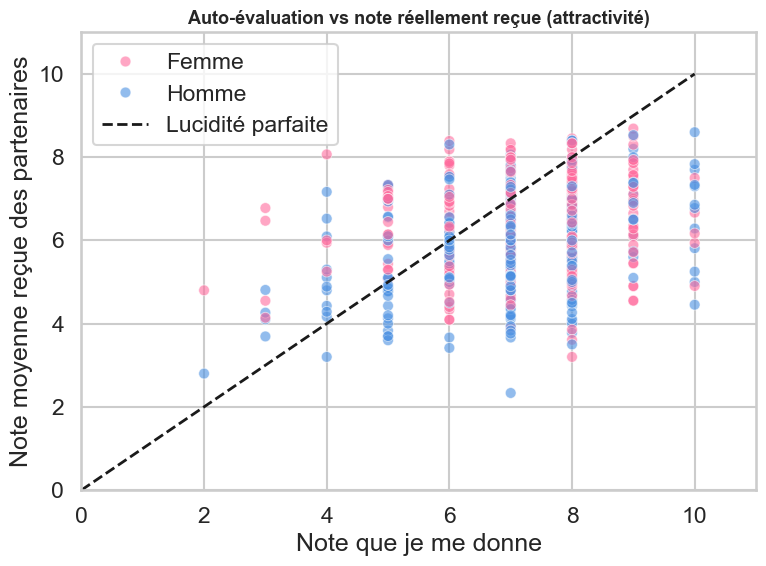

Écart moyen auto-évaluation − note reçue :
Genre
Femme    0.77
Homme    1.02
dtype: float64


In [5]:
note_recue = df.groupby('iid')['attr_o'].mean()
note_self  = df.groupby('iid')['attr3_1'].mean()
genre      = df.groupby('iid')['gender'].first().map({0: 'Femme', 1: 'Homme'})
df_q4 = pd.concat([note_recue, note_self, genre], axis=1).dropna()
df_q4.columns = ['Note reçue', 'Auto-évaluation', 'Genre']

ecart = df_q4.groupby('Genre')['Auto-évaluation'].mean() - df_q4.groupby('Genre')['Note reçue'].mean()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_q4, x='Auto-évaluation', y='Note reçue',
                hue='Genre', palette={'Femme': '#ff6b9d', 'Homme': '#4a90e2'},
                alpha=0.6, s=60)
plt.plot([0, 10], [0, 10], 'k--', lw=2, label='Lucidité parfaite')
plt.title('Auto-évaluation vs note réellement reçue (attractivité)', fontsize=13, weight='bold')
plt.xlabel('Note que je me donne')
plt.ylabel('Note moyenne reçue des partenaires')
plt.legend()
plt.xlim(0, 11); plt.ylim(0, 11)
plt.tight_layout()
plt.show()

print('Écart moyen auto-évaluation − note reçue :')
print(ecart.round(2))

**Résultat clé :** Les gens se surestiment de **+1 point (hommes)** et **+0,8 point (femmes)** en moyenne. Quasi personne ne se sous-estime. La quasi-totalité des points est **au-dessus de la diagonale**.

---
## Q5 — Mieux vaut-il passer en premier ou en dernier ?

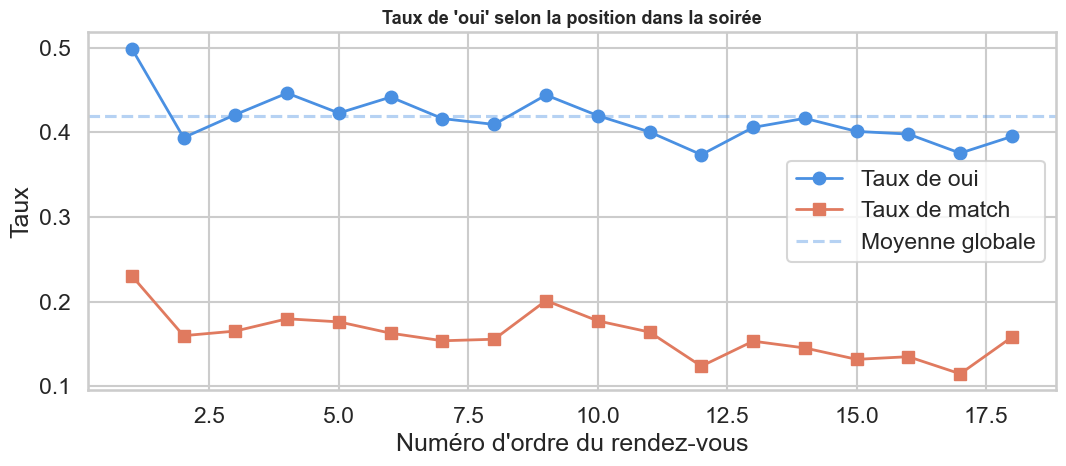

Début (1-3) : 43.8%   |   Fin (≥15) : 40.0%   |   Écart : 3.8%


In [6]:
ordre_stats = df.groupby('order').agg(
    taux_oui=('dec', 'mean'),
    taux_match=('match', 'mean'),
    n=('dec', 'size')
).reset_index()
ordre_stats = ordre_stats[ordre_stats['n'] >= 200]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ordre_stats['order'], ordre_stats['taux_oui'],
        marker='o', lw=2, label='Taux de oui', color='#4a90e2')
ax.plot(ordre_stats['order'], ordre_stats['taux_match'],
        marker='s', lw=2, label='Taux de match', color='#e07a5f')
ax.axhline(df['dec'].mean(), ls='--', color='#4a90e2', alpha=0.4, label='Moyenne globale')
ax.set_title("Taux de 'oui' selon la position dans la soirée", fontsize=13, weight='bold')
ax.set_xlabel("Numéro d'ordre du rendez-vous")
ax.set_ylabel('Taux')
ax.legend()
plt.tight_layout()
plt.show()

debut = df[df['order'] <= 3]['dec'].mean()
fin   = df[df['order'] >= 15]['dec'].mean()
print(f"Début (1-3) : {debut:.1%}   |   Fin (≥15) : {fin:.1%}   |   Écart : {debut - fin:.1%}")

**Résultat clé :** Légère baisse du taux de « oui » au fil de la soirée : **44 %** au début vs **40 %** en fin (−4 pts). Effet réel mais modeste — mieux vaut passer **en premier**.

---
## Conclusion — 3 recommandations pour Tinder

**Ce qui détermine vraiment un match (ordre d'importance réelle) :**

| # | Facteur | Corrélation avec la décision |
|---|---------|:---:|
| 1 | Physique (`attr`) | **0,49** |
| 2 | Fun | 0,41 |
| 3 | Intérêts communs | 0,40 |
| 4 | Intelligence | 0,21 |
| 5 | Ambition | 0,18 |

---

**Recommandation 1 — La photo reste reine**  
Le physique est le facteur n°1 réel alors qu'il est sous-déclaré. Conseils photo, recadrage automatique et aide à la sélection → impact direct sur les matchs.

**Recommandation 2 — Combler le décalage perception/réalité**  
Les utilisateurs se surestiment d'1 point en moyenne. Une fonctionnalité d'« audit de profil » améliorerait l'adéquation offre/demande et réduirait les frustrations.

**Recommandation 3 — Limiter la fatigue de swipe**  
L'effet « position » montre que la qualité de décision se dégrade avec le volume. Limiter le nombre quotidien de profils ou introduire des pauses actives maintiendrait l'engagement.

---

> **Limite :** Données de 2002–2004, jeunes diplômés new-yorkais, rendez-vous de 4 minutes en face à face. Les tendances sont indicatives — à valider sur des données récentes d'app mobile.